<a href="https://colab.research.google.com/github/AChierici84/ProfessionAI/blob/main/Previsione_mercato_immobiliare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Un modello di previsione per il mercato immobiliare

RealEstateAI Solutions si propone di ottimizzare la valutazione dei prezzi immobiliari attraverso l'uso di tecniche avanzate di regolarizzazione in modelli di regressione lineare. L'obiettivo è fornire previsioni di prezzo più accurate e affidabili, riducendo il rischio di overfitting e migliorando la capacità di generalizzazione del modello.

Nel settore immobiliare, ottenere stime precise dei prezzi delle proprietà è cruciale per prendere decisioni informate. Tuttavia, i modelli di regressione lineare tradizionali possono soffrire di overfitting, compromettendo l'accuratezza delle previsioni. È necessario esplorare metodi di regolarizzazione efficaci per migliorare le performance predittive e gestire la complessità del modello.

Implementando e confrontando metodi di regolarizzazione come Lasso, Ridge e Elastic Net, RealEstateAI Solutions offrirà un sistema in grado di fornire previsioni di prezzo immobiliari più accurate e stabili. Questo permetterà agli agenti immobiliari e agli investitori di prendere decisioni basate su dati più affidabili, aumentando la loro competitività nel mercato.

**Requisiti del Progetto:**
1. **Preparazione del Dataset**
  *   Caricamento e preprocessamento dei dati sui prezzi immobiliari.
  *   Gestione dei valori mancanti, codifica delle variabili categoriche e normalizzazione/scalatura dei dati.

2. **Implementazione dei Modelli di Regressione:**
  * **Ridge Regression**: Implementazione e addestramento del modello con regolarizzazione Ridge.
  * **Lasso Regression**: Implementazione e addestramento del modello con regolarizzazione Lasso.
  * **Elastic Net Regression**: Implementazione e addestramento del modello con regolarizzazione Elastic Net.
3. **Valutazione delle Performance:**
 * Utilizzo di tecniche di validazione incrociata.
 * Calcolo del Mean Squared Error (MSE) per ciascun modello.
 * Confronto della complessità dei modelli valutando il numero di coefficienti non nulli.
 * Analisi e confronto dei risultati dei vari metodi di regolarizzazione.
4. **Visualizzazione dei Risultati:**
 * Creazione di grafici per visualizzare e confrontare le performance dei modelli.
 * Visualizzazione della distribuzione dei residui per valutare l'adeguatezza del modello.

Il progetto deve includere il codice sorgente completo, con commenti dettagliati che spiegano i vari passaggi, le scelte fatte e i risultati ottenuti, per garantire trasparenza e replicabilità del lavoro.


##Il Dataset

Il dataset è disponibile qui: https://proai-datasets.s3.eu-west-3.amazonaws.com/housing.csv (liberamente tratto dal seguente dataset: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

 * **Price:** il prezzo, il target da prevedere
 * **Area:** superficie dell’immobile
 * **Bedrooms:** numero di camere da letto
 * **Bathrooms:** numero di bagni
 * **Stories:** numero di piani
 * **Mainroad:** vale 1 se l’immobile affaccia su una strada principale, 0 altrimenti
 * **guestroom:** vale 1 se l’immobile ha una stanza degli ospiti, 0 altrimenti
 * **basement:** vale 1 se l’immobile ha un seminterrato, 0 altrimenti
 * **hotwaterheating:** vale 1 se l’immobile ha una caldaia, 0 altrimenti
 * **airconditioning:** vale 1 se l’immobile ha l’aria condizionata, 0 altrimenti
 * **parking:** numero di parcheggi
 * **prefarea:** vale 1 se l’immobile è in una zona prestigiosa, 0 altrimenti
 * **Furnishingstatus:** vale 0 se l’immobile non è arredato, 1 se è parzialmente arredato, 2 se è completamente arredato


##Caricamento del dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

BASE_URL="https://proai-datasets.s3.eu-west-3.amazonaws.com/"

RANDOM_STATE=0

# disattiva la notazione scientifica
np.set_printoptions(suppress=True, precision=6)

df=pd.read_csv(BASE_URL+ "housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1


##Preparazione

Eliminiamo la colonna price che costituisce il target del modello.


In [ ]:
df_features=df.drop("price", axis=1)
df_features.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,1
1,8960,4,4,4,1,0,0,0,1,3,0,1
2,9960,3,2,2,1,0,1,0,0,2,1,2
3,7500,4,2,2,1,0,1,0,1,3,1,1
4,7420,4,1,2,1,1,1,0,1,2,0,1


Tutte le feature sono quantitative, non sono necessarie operazioni di Encoding.

### Dati mancanti

Valutiamo la numerosità dei dati e la presenza di dati mancanti.

In [ ]:
df_features.count()

,0
area,545
bedrooms,545
bathrooms,545
stories,545
mainroad,545
guestroom,545
basement,545
hotwaterheating,545
airconditioning,545
parking,545


In [ ]:
df_features.isna().sum()

,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0
parking,0


Non sembrano esserci dati mancanti.


#Matrice di Correlazione

Analizziamo la matrice di correlazione per valutare quali metriche sembrano maggiormente correlate al target

<Axes: >

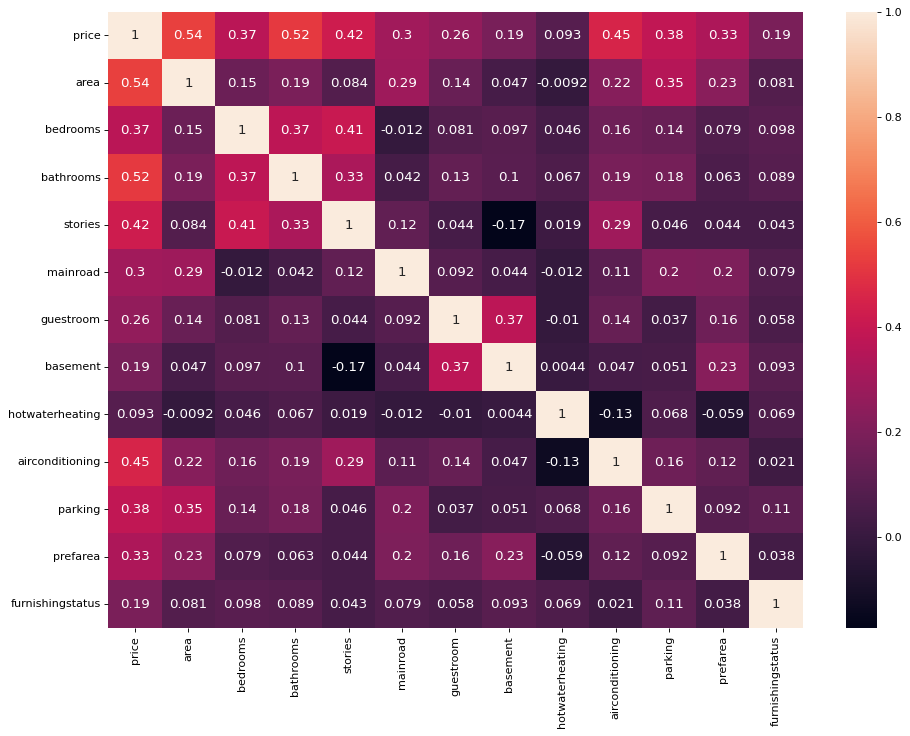

In [ ]:
plt.figure(figsize=(14, 10), dpi=80)

sns.heatmap(df.corr(),
            annot=True,
            xticklabels=df.columns,
            yticklabels=df.columns,
            annot_kws={'size':12}
            )

##Normalizzazione/scalatura dei dati

La feature Area ha valori molti più grandi delle altre feature, procederemo a scalare i dati e normalizzarli.

In [ ]:
for col in df_features.columns:
  print(f"{col} - Min: {df_features[col].min()}, Max: {df_features[col].max()}")

area - Min: 1650, Max: 16200
bedrooms - Min: 1, Max: 6
bathrooms - Min: 1, Max: 4
stories - Min: 1, Max: 4
mainroad - Min: 0, Max: 1
guestroom - Min: 0, Max: 1
basement - Min: 0, Max: 1
hotwaterheating - Min: 0, Max: 1
airconditioning - Min: 0, Max: 1
parking - Min: 0, Max: 3
prefarea - Min: 0, Max: 1
furnishingstatus - Min: 0, Max: 2


Normalizziamo l'area che è il dato fuori scala.

In [ ]:
df_scaled=df_features.copy()
to_norm=df_scaled["area"]
to_std=df_scaled["area"]
df_scaled["area"]=(to_norm-to_norm.mean())/to_norm.std()
df_scaled.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,1.045766,4,2,3,1,0,0,0,1,2,1,1
1,1.755397,4,4,4,1,0,0,0,1,3,0,1
2,2.216196,3,2,2,1,0,1,0,0,2,1,2
3,1.082630,4,2,2,1,0,1,0,1,3,1,1
4,1.045766,4,1,2,1,1,1,0,1,2,0,1


In [ ]:
for col in df_scaled.columns:
  print(f"{col} - Min: {df_scaled[col].min()}, Max: {df_scaled[col].max()}")

area - Min: -1.6130478379496513, Max: 5.091585570242134
bedrooms - Min: 1, Max: 6
bathrooms - Min: 1, Max: 4
stories - Min: 1, Max: 4
mainroad - Min: 0, Max: 1
guestroom - Min: 0, Max: 1
basement - Min: 0, Max: 1
hotwaterheating - Min: 0, Max: 1
airconditioning - Min: 0, Max: 1
parking - Min: 0, Max: 3
prefarea - Min: 0, Max: 1
furnishingstatus - Min: 0, Max: 2


Ora le colonne sono tutte nello stesso range di valori. Procedo alla normalizzazione.

In [ ]:
#ss= StandardScaler()
#X_std=ss.fit_transform(df_scaled.values)
#print(f"Media: {X_std.mean()} Deviazione Standard: {X_std.std()}")

mm= MinMaxScaler()
X_mm=mm.fit_transform(df_scaled.values)
print(f"Min: {X_mm.min()} Max: {X_mm.max()}")

Min: 0.0 Max: 1.0000000000000002


##Regressione Lineare

Procedo a dividere i dati in train e test set.

In [ ]:
X=X_mm
y=df["price"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=RANDOM_STATE)

Definiamo le funzioni di valutazione per le metriche

In [ ]:
def evaluate(model, data):
    X,y = data
    y_pred = model.predict(X)
    return {
        'MSE': mean_squared_error(y, y_pred),
        'R2': r2_score(y, y_pred)
        }

def evaluate_all(model, train_data, test_data):
    return {'train': evaluate(model, train_data), 'test': evaluate(model, test_data)}

def plot_residuals(model, data, poly=None):
    X_test,y_test=data
    if poly is not None:
        y_pred = model.predict(poly.transform(X_test))
    else:
      y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('Valori Predetti')
    plt.ylabel('Residui')
    plt.title('Residui vs Valori Predetti')
    plt.show()

def plot_all_residuals(models,data,poly):
    X_test,y_test=data
    for name, model in models.items():
        x_test_poly=poly.transform(X_test)
        y_pred = model.predict(x_test_poly)
        residuals = y_test - y_pred
        plt.scatter(y_pred, residuals, label=name)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('Valori Predetti')
    plt.ylabel('Residui')
    plt.title('Residui vs Valori Predetti - Confronto Modelli')
    plt.legend()
    plt.show()

def plot_all_coeff(models):
    plt.figure(figsize=(10, 6))
    for name, model in models.items():
        plt.plot(range(len(model.coef_)), model.coef_, label=name)
    plt.xticks(rotation=90)
    plt.legend()
    plt.title("Confronto coefficienti tra modelli")
    plt.xlabel("Feature")
    plt.ylabel("Valore coefficiente")
    plt.show()

Implementiamo una Regressione Lineare di base


In [ ]:
lr= LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

Valutiamo la Regressione Lineare:

In [ ]:
evaluate_all(lr, (X_train,y_train), (X_test,y_test))

{'train': {'MSE': 1204930725280.4263, 'R2': 0.6559473625442808},
 'test': {'MSE': 961887082256.528, 'R2': 0.7227011810334026}}

Calcoliamo i residui, ossia la differenza tra valore reale e valore predetto sul test set.

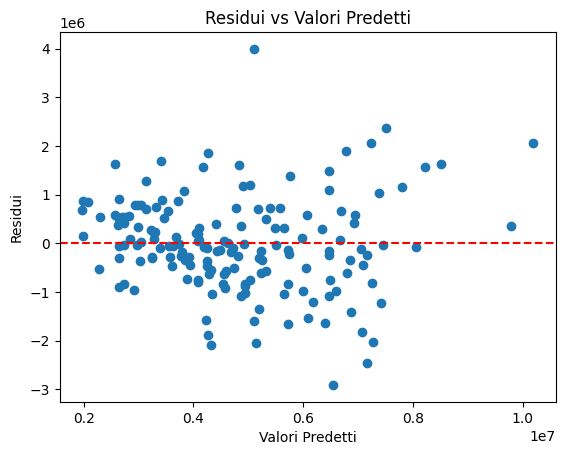

In [ ]:
plot_residuals(lr,(X_test,y_test))

## Regressione Polinomiale

Dato che i risultati sono discreti, ma potrebbero essere migliori, valutiamo l'adozione di una Regressione Polinomiale

In [ ]:
#gradi del polinomio
degrees=[2,3,4,5]

for degree in degrees:
  poly=PolynomialFeatures(degree=degree)
  x_train_poly=poly.fit_transform(X_train)
  x_test_poly=poly.transform(X_test)
  lr=LinearRegression()
  lr.fit(x_train_poly,y_train)
  print(f"Grado {degree}")
  print(evaluate_all(lr,(x_train_poly,y_train),(x_test_poly,y_test)))

Grado 2
{'train': {'MSE': 801017365922.154, 'R2': 0.7712796830463338}, 'test': {'MSE': 1869241658579.295, 'R2': 0.4611233336544953}}
Grado 3
{'train': {'MSE': 132077592460.6018, 'R2': 0.9622869239853636}, 'test': {'MSE': 251435456567608.2, 'R2': -71.48538465550409}}
Grado 4
{'train': {'MSE': 18459476393.39739, 'R2': 0.9947291313882615}, 'test': {'MSE': 5.524116205369119e+16, 'R2': -15924.267402380714}}
Grado 5
{'train': {'MSE': 14892082257.007885, 'R2': 0.9957477553935404}, 'test': {'MSE': 1.6150858250427967e+19, 'R2': -4656069.344175999}}


R2 raggiunge il valore 0.77 per il polinomio di grado 2. Per i gradi maggiori o uguali a 3, invece, abbiamo un probabile OVERFITTING dato che l'R2 viene molto vicino a 1 per il train set e viceversa sprofonda sotto lo zero per il test set. Mi salvo pertanto il modello di grado 2.

In [ ]:
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(X_train)
x_test_poly=poly.transform(X_test)
lr_poly2=LinearRegression()
lr_poly2.fit(x_train_poly,y_train)

LinearRegression()

Valutazioni metriche:

In [ ]:
evaluate_all(lr_poly2,(x_train_poly,y_train),(x_test_poly,y_test))

{'train': {'MSE': 801017365922.154, 'R2': 0.7712796830463338},
 'test': {'MSE': 1869241658579.295, 'R2': 0.4611233336544953}}

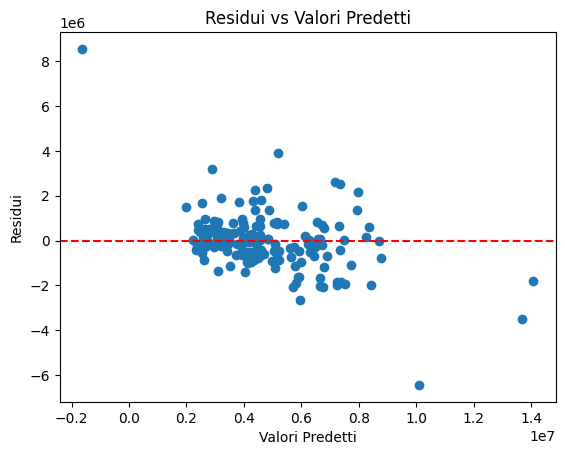

In [ ]:
plot_residuals(lr_poly2,(X_test,y_test),poly=poly)

In effetti dal grafico dei residui il modello sembra migliore, la "nuvola" dei residui tende ad "ammassarsi" vicino allo 0 in maniera molto più compatta.

##Valutazione Modello

###Cross Validation

Verifico quanto bene il modello polinomiale di grado 2 riesce a generalizzare su dati nuovi mediante tecnica di validazione incrociata.


In [ ]:
from sklearn.model_selection import KFold,cross_validate

lr=LinearRegression()

x_poly=poly.transform(X)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_validate(lr, x_poly, y, cv=cv, scoring=['r2'],return_train_score=True) #cv = batch
cv_scores

{'fit_time': array([0.005404, 0.005724, 0.00577 , 0.005567, 0.005557]),
 'score_time': array([0.001435, 0.001346, 0.001369, 0.001331, 0.001337]),
 'test_r2': array([0.274798, 0.603787, 0.519432, 0.581194, 0.537547]),
 'train_r2': array([0.778711, 0.76616 , 0.787316, 0.77481 , 0.786295])}

Dai risultati si può vedere che il tempo di addestramento è basso (fit_time), il calcolo degli score è molto veloce quindi il modello sembra abbastanza leggero. Calcolo la media sugli R2.

In [ ]:

print(f"Train R2: {cv_scores['train_r2'].mean()} Test R2: {cv_scores['test_r2'].mean()}")

Train R2: 0.7786583377237521 Test R2: 0.5033516068622609


R2 per il train set è 0.77, il modello riesce a catturare abbastanza informazioni sul set di apprendimento.

R2 per il test è 0.50 che è basso. Potrebbe esserci un problema di  Overfitting.

Tentiamo alcune tecniche di regolarizzazione per tentare di risolvere l'overfitting.

##Regolarizzazione

###RIDGE REGRESSION (L2)

Ricerchiamo il lambda (parametro alpha) migliore nell'intervallo.

In [ ]:
from sklearn.linear_model import Ridge,RidgeCV
alphas = np.logspace(-6, 6, 100)
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(x_train_poly, y_train)
print("Miglior alpha Ridge:", ridge.alpha_)
best_alpha=ridge.alpha_

Miglior alpha Ridge: 8.111308307896872


Definiamo un modello con questo valore di lambda (parametro alpha)

In [ ]:
ridge=Ridge(alpha=best_alpha) #lambda
ridge.fit(x_train_poly,y_train)

Ridge(alpha=np.float64(8.111308307896872))

Valutiamo il modello ottenuto

In [ ]:
evaluate_all(ridge,(x_train_poly,y_train),(x_test_poly,y_test))

{'train': {'MSE': 1046951829834.9948, 'R2': 0.7010562260664491},
 'test': {'MSE': 946812056044.7992, 'R2': 0.7270471037945194}}

Ridge risolve l'overfitting: la R2 sul test set sale a 0.72. La precisione sul train set invece sxcende da 0.77 a 0.70.

Studio i coefficenti.

In [ ]:
non_zero = np.sum(ridge.coef_ != 0)
print(f"{non_zero}/{ridge.coef_.shape[0]} coefficienti non nulli")
print(f"{ridge.coef_}")

89/91 coefficienti non nulli
[      0.        750421.780768  241021.680243  586889.746577
  334199.869464   62729.696784  117273.622104   84359.310312
  195025.950916  278451.393226  169766.995388   98999.534245
  379327.773965  270519.037303  346737.345178  353786.39216
  216737.506298  715415.259214   -7890.634026  350134.839059
   57244.266608  268600.253381  201184.872899  224773.044689
  324503.430621  122245.776594  287213.571301  130630.167155
  194637.294418   77107.92782   132966.825244  222199.557371
  183598.826063  250021.511454   47777.037462   86745.879352
  242372.948969  282097.408856  699525.413073  -51711.737106
   74239.311371   47773.343978  524200.585726  449493.119277
  588875.781399  221571.20071   329572.895976  301815.619908
 -150342.938179    2184.909625  134270.990151  340403.286617
  308871.516728  297041.2369    -28618.707587   62729.696784
  206257.412831   47392.613872  382336.28487   154678.66152
  309477.08695   152561.604528   67752.21844   117273.6221

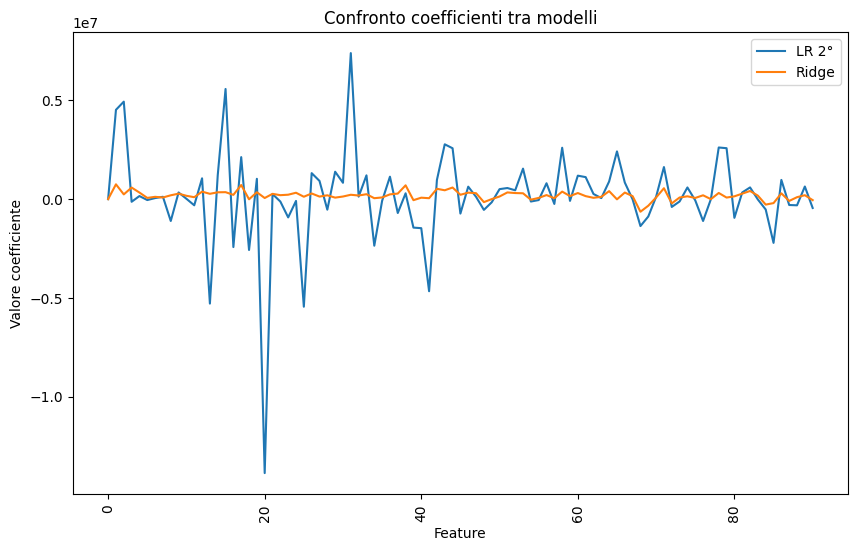

In [ ]:
plot_all_coeff(models = {'LR 2°':lr_poly2,'Ridge': ridge})

In **Ridge** i coefficienti del modello vengono ridotti in valore assoluto rispetto a quelli di regressione polinomiale classica.

Calcolo i residui ...

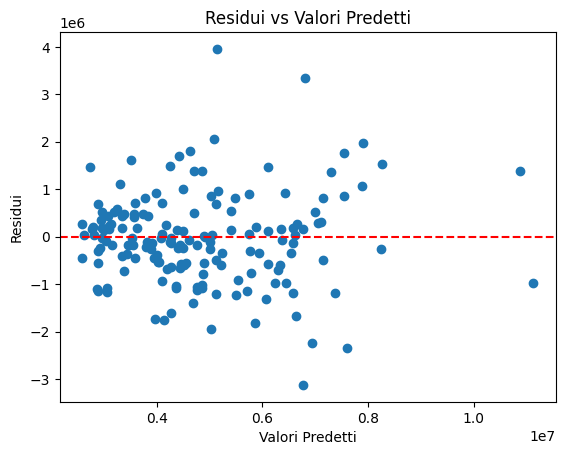

In [ ]:
plot_residuals(ridge, (X_test,y_test),poly=poly)

La "nuvola" dei residui è abbastanza adiacente lo zero anche se visimente meno densa della polinomiale di base (che però soffriva di over fitting).  

###Lasso Regression (L1)

Ricerchiamo il lambda (parametro alpha) migliore nell'intervallo.

In [ ]:
from sklearn.linear_model import Lasso,LassoCV

lasso = LassoCV(alphas=alphas, cv=10)
lasso.fit(x_train_poly, y_train)
print("Miglior alpha Lasso:", lasso.alpha_)
best_alpha=lasso.alpha_

Miglior alpha Lasso: 3764.9358067924713


Instanzio un modello coi parametri trovati.

In [ ]:
from sklearn.linear_model import Lasso

lasso=Lasso(alpha=best_alpha)
lasso.fit(x_train_poly,y_train)

Lasso(alpha=np.float64(3764.9358067924713))

Valuto il modello risultante.

In [ ]:
evaluate_all(lasso,(x_train_poly,y_train),(x_test_poly,y_test))

{'train': {'MSE': 940560029829.4451, 'R2': 0.7314350508632455},
 'test': {'MSE': 1036600321054.5964, 'R2': 0.7011623816649042}}

La regolarizzazione Lasso aumenta la R2 sul test set a 0.70 risolvendo l'OVERFITTING. Sul train set la R2 si abbassa a 0.73.

Valutiamo ora i coefficienti.

In [ ]:
non_zero = np.sum(lasso.coef_ != 0)
print(f"{non_zero}/{lasso.coef_.shape[0]} coefficienti non nulli")
print(f"{lasso.coef_}")

43/91 coefficienti non nulli
[       0.        1920398.478368   687638.365829   256667.287721
   396537.134442        0.              0.          41149.696442
        0.         682633.974161        0.              0.
   547590.613506       -0.              0.              0.
        0.        1053952.575609       -0.         584437.32833
       -0.              0.              0.              0.
       -0.              0.              0.              0.
        0.              0.              0.              0.
        0.              0.             -0.              0.
        0.              0.        1209507.361411       -0.
  -313700.582828       -0.        1004379.571674  1848226.991934
  1893776.145383        0.         214150.189645   379726.340274
  -159424.13223        -0.              0.         506537.892216
   192002.900892   452568.442442       -0.              0.
   425629.044238    23056.539329   744002.615019        0.
   601126.208699   146933.190191        0.         

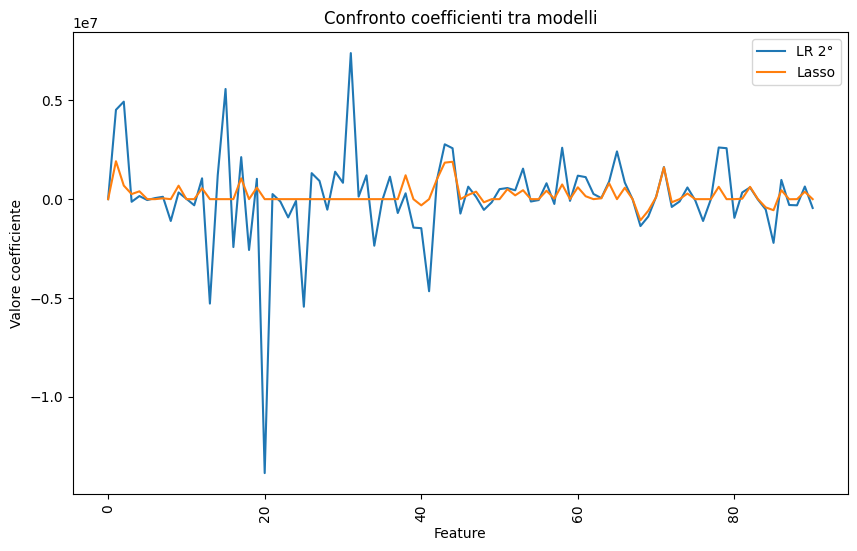

In [ ]:
plot_all_coeff(models = {'LR 2°':lr_poly2,'Lasso': lasso})

**Lasso** seleziona le feature rilevanti, mandando a zero i coefficenti di quelle poco rilevanti, creando così un modello sparso, con molti coefficienti nulli come si può notare dalla lista sovrastante.

Calcolo i residui ...

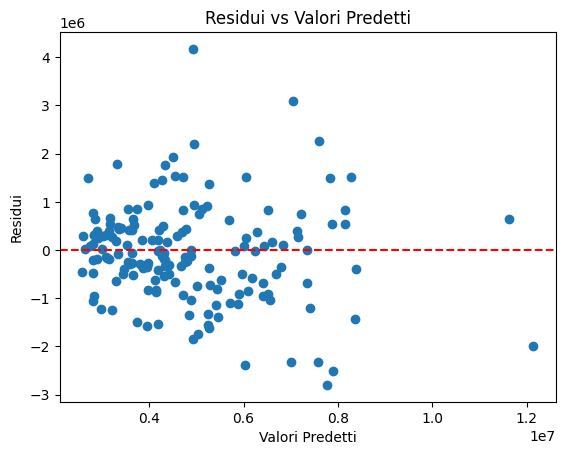

In [ ]:
plot_residuals(lasso,(X_test,y_test), poly=poly)

Anche in questo caso i residui tendono a schiacciarsi sull'asse dello 0 con alcuni valori che persistono in aree più esterne.

###ElasticNet Regression( bilancia L1 e L2)



Tentiamo infine con una combinazione delle due strategie tramite ElasticNet regression.

Cerchiamo i parametri migliori per la regolarizzazione in un intervallo.

In [ ]:
from sklearn.linear_model import ElasticNet,ElasticNetCV

alphas = np.logspace(-4, 1, 50)

elastic=ElasticNetCV(l1_ratio=.5,
                 alphas=alphas,
                 cv=10,
                 max_iter=10000)
elastic.fit(x_train_poly, y_train)
print("Miglior alpha ElasticNet:", elastic.alpha_)
print("Miglior l1_ratio ElasticNet:", elastic.l1_ratio_)
best_alpha=elastic.alpha_
best_l1_ratio=elastic.l1_ratio_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 581731939912.25, tolerance: 115700815913.3398
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 29099127433709.453, tolerance: 115700815913.3398
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 118387787104635.05, tolerance: 115700815913.3398
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWar

Miglior alpha ElasticNet: 0.028117686979742307
Miglior l1_ratio ElasticNet: 0.5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 139100483595037.5, tolerance: 120832792287.76859
  model = cd_fast.enet_coordinate_descent_gram(


Il modello fatica a convergere nel numero di iterazioni fornite, per cui i risultati potrebbero non essere ottimali.
Istanziamo il modello ottenuto per valutarne le metriche.

In [ ]:
elastic=ElasticNet(alpha=best_alpha,l1_ratio=best_l1_ratio)
elastic.fit(x_train_poly,y_train)

ElasticNet(alpha=np.float64(0.028117686979742307), l1_ratio=np.float64(0.5))

In [ ]:
evaluate_all(elastic,(x_train_poly,y_train),(x_test_poly,y_test))

{'train': {'MSE': 1009848191997.4343, 'R2': 0.7116506977562995},
 'test': {'MSE': 937636269395.2231, 'R2': 0.729692356909935}}

Il modello elastic.net non riesce a convergere bene, anche portando le iterazionia 10000. Manteniamo un l1-ratio medio.

R2 sul train set anche in questo caso scende a 0.71.

L'R2 del test set si alza fino a 0.72, quindi risulta essere una buona soluzione all'OVERFITTING della regressione polinomiale.

Valutiamo i coefficienti.

In [ ]:
non_zero = np.sum(elastic.coef_ != 0)
print(f"{non_zero}/{elastic.coef_.shape[0]} coefficienti non nulli")
print(f"{elastic.coef_}")

89/91 coefficienti non nulli
[      0.        862499.669356  266319.519476  599691.772433
  340259.458823   53765.834617  122210.041823   81368.031284
  159823.800214  296109.105588  155584.84064    68091.56546
  474975.927137  243487.709786  388937.812113  422971.177315
  210416.591366  811541.888275  -45701.283697  431067.143308
   39770.551166  283329.244375  188737.403594  207565.787184
  331888.51851    96697.683382  290206.287768  108502.093522
  189229.09305    82860.233089  140750.737919  252905.174218
  180848.161505  288868.940632    2157.772024   72962.644534
  255638.217174  285822.997668  767962.636783 -132078.652256
     252.353099   25341.477115  632385.737189  559198.667455
  733289.038568  189653.750838  329385.921231  296461.815598
 -215766.359121   -7709.029147  136871.029249  364012.550909
  338914.239527  365036.278656  -64411.238682   53765.831998
  247129.157353   37353.21154   426497.810583  110665.419123
  348984.568598  147073.68558    53345.141097  122210.021

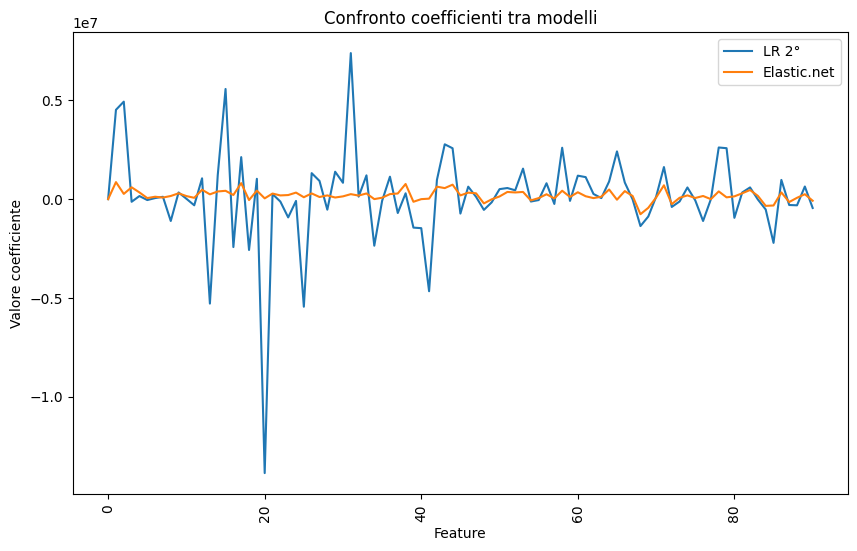

In [ ]:
plot_all_coeff(models = {'LR 2°':lr_poly2,'Elastic.net': elastic})

La maggior parte dei coefficienti è valorizzata, anche se il loro valore è stato decisamente attenuato.

Calcolo i residui...

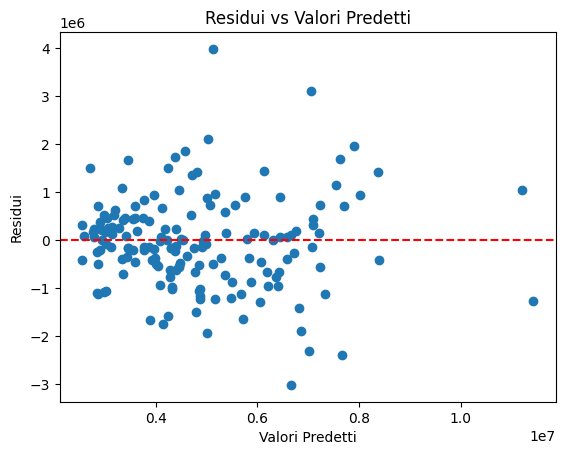

In [ ]:
plot_residuals(elastic, (X_test,y_test),poly=poly)

La "nuvola" dei residui è abbastanza schiacciata sull'asse 0, ma permangono valori esterni.

##Confronto Coefficienti dei modelli Ridge, Lasso, Elastic.net

Verifichiamo il diverso smorzamento sui coefficienti fatto dai tre tipi di regolarizzazione.

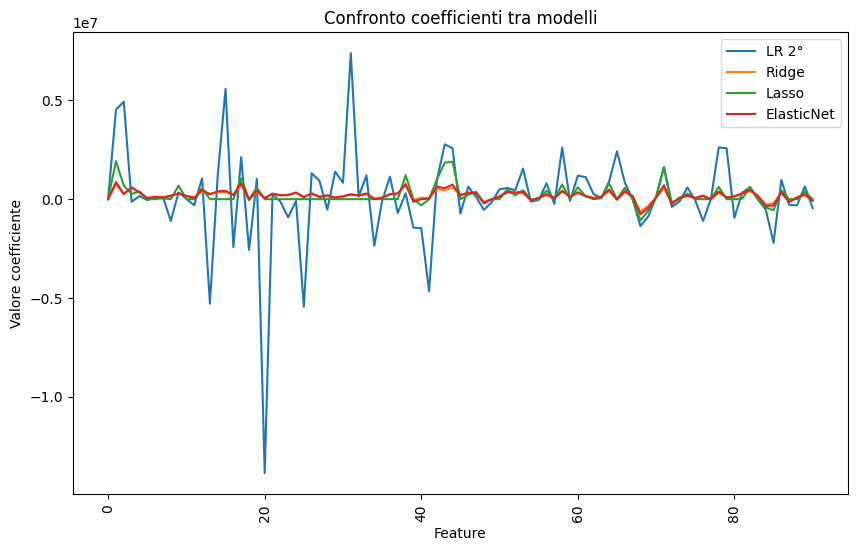

In [ ]:
plot_all_coeff(models = {'LR 2°':lr_poly2,'Ridge': ridge, 'Lasso': lasso, 'ElasticNet': elastic})

Come si nota dal grafico i coefficienti di LR 2° sono stati abbassati in valore assoluto o azzerati per attuare la regolarizzazione.

Se ci limitiamo a visualizzare solo i coeffidcenti dei modelli di regolarizzzione vediamo come il Lasso tenda ad annullare drasticamente a zero numerosi coefficenti,mentre il Ridge ed Elastic.net tendono piuttosto ad attenuarli.

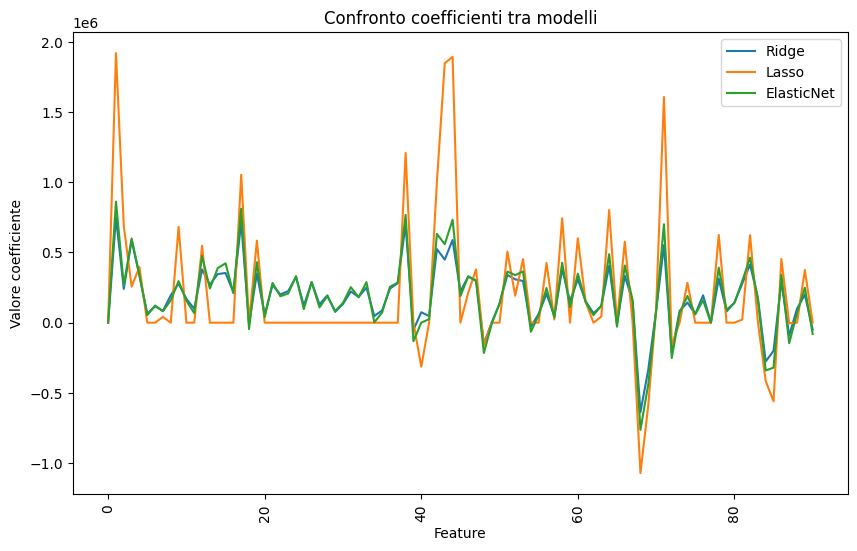

In [ ]:
plot_all_coeff(models = {'Ridge': ridge, 'Lasso': lasso, 'ElasticNet': elastic})

Creiamo un dataframe di confronto.

In [ ]:
# esempio: Lasso, Ridge, Elastic.Net
models = {'LR 2°':lr_poly2,'Ridge': ridge, 'Lasso': lasso, 'ElasticNet': elastic}
coefs = pd.DataFrame({name: m.coef_ for name, m in models.items()}, index=range(len(ridge.coef_)))
coefs

,LR 2°,Ridge,Lasso,ElasticNet
0,3.237234e-09,0.000000,0.000000e+00,0.000000
1,4.523806e+06,750421.780768,1.920398e+06,862499.669356
2,4.937950e+06,241021.680243,6.876384e+05,266319.519476
3,-1.333329e+05,586889.746577,2.566673e+05,599691.772433
4,1.572213e+05,334199.869464,3.965371e+05,340259.458823
...,...,...,...,...
86,9.745503e+05,294242.012095,4.539728e+05,340004.397495
87,-2.965456e+05,-91368.669961,-4.499969e+03,-146293.979730
88,-3.119158e+05,98999.534245,0.000000e+00,68091.563458
89,6.395674e+05,199989.443726,3.754785e+05,249485.635679


Disegniamo in un grafico a barre per valutare meglio la portata dello smorzamento dei coefficienti.

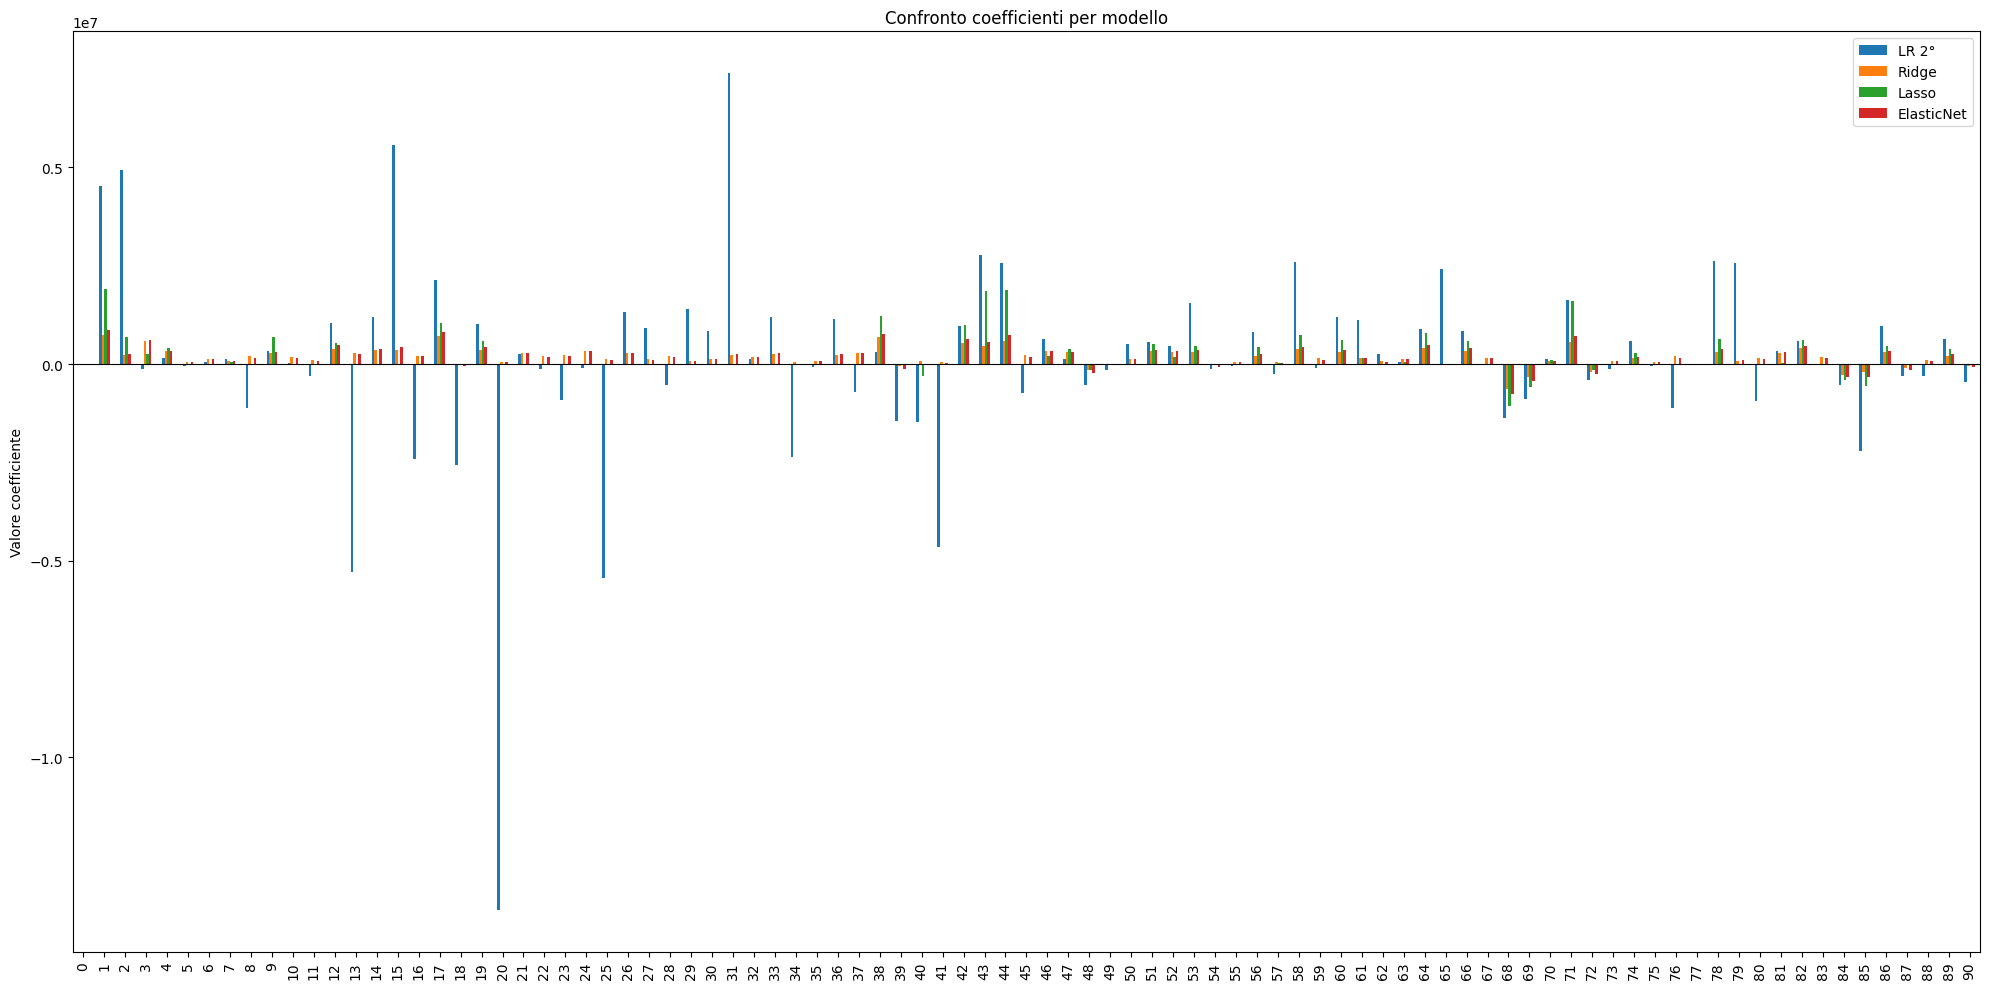

In [ ]:
# grafico a barre
coefs.plot(kind='bar', figsize=(20, 10))
plt.title("Confronto coefficienti per modello")
plt.ylabel("Valore coefficiente")
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Come si nota dal grafico i coefficienti di LR 2 sono stati abbassati in valore assoluto o azzerati per attuare la regolarizzazione.

##Confronto residui

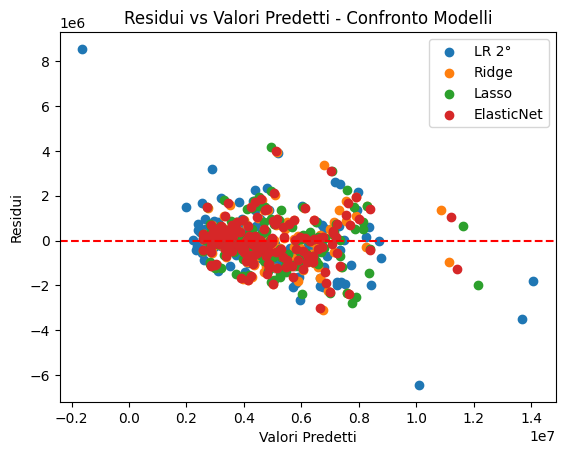

In [ ]:
plot_all_residuals({'LR 2°':lr_poly2,'Ridge': ridge, 'Lasso': lasso, 'ElasticNet': elastic},(X_test,y_test),poly=poly)

I residui sono sparsi sopra e sotto la linea dello zero.

La maggior parte si concentra attorno ad esso per cui i modelli non hanno bias sistematico evidente.

I tre modelli hanno residui molto simili nella zona centrale (valori predetti tra 0.3 e 0.8).

Le differenze emergono negli outlier: per valori predetti più alti, i residui di Lasso e Ridge sembrano leggermente più grandi.

Il modello di Regressione polinomiale presentava meno outlier, soffriva però di Overfitting (basse prestazioni sul test set).

##Learning Curve

Curve di apprendimento dei modelli.



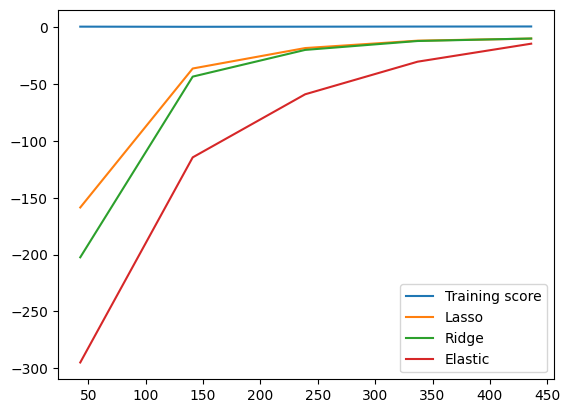

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes_abs, train_scores, test_scores = learning_curve(
    Lasso(),
    X,
    y,
    random_state=RANDOM_STATE,
)

train_sizes_abs_ridge, train_scores_ridge, test_scores_ridge = learning_curve(
    Ridge(),
    X,
    y,
    random_state=RANDOM_STATE,
)

train_sizes_abs_elastic, train_scores_elastic, test_scores_elastic = learning_curve(
    ElasticNet(),
    X,
    y,
    random_state=RANDOM_STATE,
)


plt.plot(train_sizes_abs, train_scores.mean(axis=1), label="Training score")
plt.plot(train_sizes_abs, test_scores.mean(axis=1), label="Lasso")
plt.plot(train_sizes_abs_ridge, test_scores_ridge.mean(axis=1), label="Ridge")
plt.plot(train_sizes_abs_elastic, test_scores_elastic.mean(axis=1), label="Elastic")
plt.legend()
plt.show()

Lasso sembra il più veloce a convergere dei tre modelli, avendo molti coefficienti azzerat risulta essere anche il modello più semplice. Elastic.Net invece è di gran lunga il peggiore, Ridge una via di mezzo tra i due.

##Confronto degli errori

Confrontiamo infine le metriche sul TEST set del modello con overfitting e delle regolarizzazioni proposte.

In [ ]:
metrics = {'MSE': [], 'R2': []}

# Disattiva notazione scientifica
pd.options.display.float_format = '{:.6f}'.format

models = {'LR 2°':lr_poly2,'Ridge': ridge, 'Lasso': lasso, 'ElasticNet': elastic}

for name, model in models.items():
    y_pred = model.predict(x_test_poly)
    metrics['MSE'].append(mean_squared_error(y_test, y_pred))
    metrics['R2'].append(r2_score(y_test, y_pred))

metrics_df = pd.DataFrame(metrics, index=models.keys())

metrics_df


,MSE,R2
LR 2°,1869241658579.294922,0.461123
Ridge,946812056044.799194,0.727047
Lasso,1036600321054.596436,0.701162
ElasticNet,937636269395.223145,0.729692


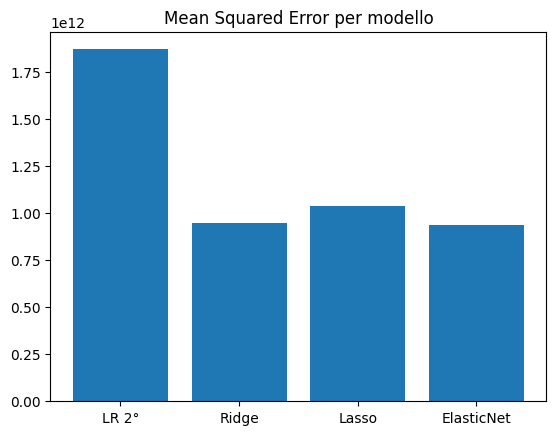

In [ ]:
plt.bar(models.keys(), metrics['MSE'])
plt.title('Mean Squared Error per modello')
plt.show()

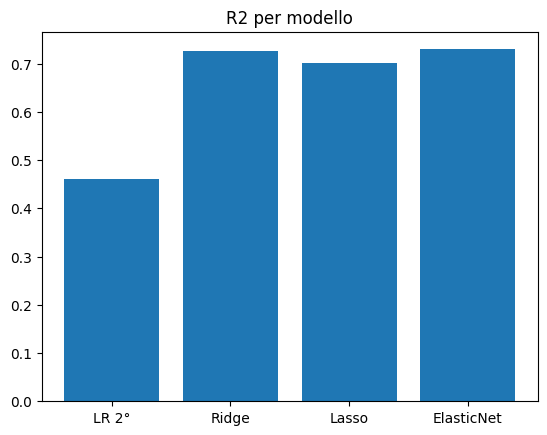

In [ ]:
plt.bar(models.keys(), metrics['R2'])
plt.title('R2 per modello')
plt.show()

Grazie alla Regolarizzazione, il Mean Squared Error è stato quasi dimezzato e l'R2 Score sul test set è salito. A presentare R2 score migliore sono il Ridge e L'Elastic.net. Quest'ultimo in particolare mescolando l'attenutazione del ridge e L'azzeramento dei coefficicneti del lasso riesce ad ottenere le percentuali migliori.

##Conclusioni

Nonostante la difficoltà a convergere il modello migliore sul test set risulta essere Elastic.net con R2: 0.7294